# Steam Engagement Thesis

## Week 1 – Dataset Inspection

### Library Imports

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical modeling
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Machine learning models
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Diagram generation
from graphviz import Digraph

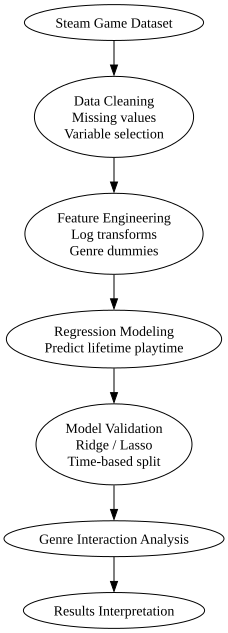

In [2]:
flow = Digraph()

flow.node("A", "Steam Game Dataset")
flow.node("B", "Data Cleaning\\nMissing values\\nVariable selection")
flow.node("C", "Feature Engineering\\nLog transforms\\nGenre dummies")
flow.node("D", "Regression Modeling\\nPredict lifetime playtime")
flow.node("E", "Model Validation\\nRidge / Lasso\\nTime-based split")
flow.node("F", "Genre Interaction Analysis")
flow.node("G", "Results Interpretation")

flow.edges(["AB","BC","CD","DE","EF","FG"])

flow.render("../Illustrations/analysis_pipeline", format="png", cleanup=True)
flow

### 1. Load and Inspect the Dataset

In [3]:
df = pd.read_csv("games.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst rows:")
display(df.head())
print("\nData types:")
df.info()
print("\nDescriptive statistics:")
display(df.describe())

Dataset Shape: (122611, 39)

Columns:
['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU', 'Required age', 'Price', 'DiscountDLC count', 'About the game', 'Supported languages', 'Full audio languages', 'Reviews', 'Header image', 'Website', 'Support url', 'Support email', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score', 'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations', 'Notes', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks', 'Developers', 'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']

First rows:


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN



Data types:
<class 'pandas.core.frame.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       122610 non-null  object 
 1   Name                        122611 non-null  object 
 2   Release date                122611 non-null  object 
 3   Estimated owners            122611 non-null  int64  
 4   Peak CCU                    122611 non-null  int64  
 5   Required age                122611 non-null  float64
 6   Price                       122611 non-null  int64  
 7   DiscountDLC count           122611 non-null  int64  
 8   About the game              114162 non-null  object 
 9   Supported languages         122611 non-null  object 
 10  Full audio languages        122611 non-null  object 
 11  Reviews                     12070 non-null   object 
 12  Header image                122530 non-null  object 
 13 

,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,Metacritic score,User score,Positive,Negative,Score rank,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Movies
count,1.226110e+05,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,1.226110e+05,1.226110e+05,40.000000,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05,122611.000000,0.0
mean,5.459332e+01,0.167611,4.765091,18.353663,0.545856,2.564941,0.024549,1.044986e+03,1.691974e+02,99.175000,18.087015,9.618250e+02,2.080232e+02,13.789268,1.735705e+02,14.722170,NaN
std,3.729452e+03,1.653591,12.531030,28.858970,14.516026,13.660559,1.394901,2.809173e+04,5.374645e+03,0.675107,141.493879,2.187880e+04,1.121768e+04,270.378053,1.120254e+04,294.509615,NaN
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
25%,0.000000e+00,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,99.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
50%,0.000000e+00,0.000000,2.240000,0.000000,0.000000,0.000000,0.000000,5.000000e+00,1.000000e+00,99.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
75%,0.000000e+00,0.000000,5.240000,40.000000,0.000000,0.000000,0.000000,3.700000e+01,1.000000e+01,100.000000,19.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
max,1.013936e+06,21.000000,999.980000,100.000000,3703.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,100.000000,9821.000000,4.830455e+06,3.429544e+06,20088.000000,3.429544e+06,20088.000000,NaN


The dataset contains **122,611 games** across 39 columns. Column types include 19 object, 14 int64, 3 float64, and 3 bool fields. Key engagement variables (`average_playtime_forever`, `average_playtime_two_weeks`) are present and fully populated.

In [4]:
print("Dataset Shape:", df.shape)
print("\nColumn Types:")
print(df.dtypes.value_counts())

Dataset Shape: (122611, 39)

Column Types:
object     19
int64      14
float64     3
bool        3
Name: count, dtype: int64


### 2. Identify Key Variables

In [5]:
# Clean column names
df.columns = df.columns.str.lower().str.replace(" ", "_")
print(df.columns.tolist())

['appid', 'name', 'release_date', 'estimated_owners', 'peak_ccu', 'required_age', 'price', 'discountdlc_count', 'about_the_game', 'supported_languages', 'full_audio_languages', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'user_score', 'positive', 'negative', 'score_rank', 'achievements', 'recommendations', 'notes', 'average_playtime_forever', 'average_playtime_two_weeks', 'median_playtime_forever', 'median_playtime_two_weeks', 'developers', 'publishers', 'categories', 'genres', 'tags', 'screenshots', 'movies']


In [6]:
# Automatically identify variable types
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()

print("Numeric Columns:", numeric_cols)
print("\nCategorical Columns:", categorical_cols)
print("\nBoolean Columns:", bool_cols)

Numeric Columns: ['estimated_owners', 'peak_ccu', 'required_age', 'price', 'discountdlc_count', 'metacritic_score', 'user_score', 'positive', 'negative', 'score_rank', 'achievements', 'recommendations', 'average_playtime_forever', 'average_playtime_two_weeks', 'median_playtime_forever', 'median_playtime_two_weeks', 'movies']

Categorical Columns: ['appid', 'name', 'release_date', 'about_the_game', 'supported_languages', 'full_audio_languages', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'metacritic_url', 'notes', 'developers', 'publishers', 'categories', 'genres', 'tags', 'screenshots']

Boolean Columns: ['windows', 'mac', 'linux']


In [7]:
# Define engagement variables
early_engagement = [
    "average_playtime_two_weeks",
    "median_playtime_two_weeks"
]

long_term_engagement = [
    "average_playtime_forever",
    "median_playtime_forever"
]

print("Early Engagement Variables:", early_engagement)
print("Long-Term Engagement Variables:", long_term_engagement)

Early Engagement Variables: ['average_playtime_two_weeks', 'median_playtime_two_weeks']
Long-Term Engagement Variables: ['average_playtime_forever', 'median_playtime_forever']


In [8]:
# Confirm engagement variables exist in dataset
for col in early_engagement + long_term_engagement:
    print(col, "exists:", col in df.columns)

average_playtime_two_weeks exists: True
median_playtime_two_weeks exists: True
average_playtime_forever exists: True
median_playtime_forever exists: True


In [9]:
# Define static game attributes
static_attributes = [
    'price',
    'required_age',
    'genres',
    'categories',
    'developers',
    'publishers',
    'windows',
    'mac',
    'linux',
    'metacritic_score',
    'user_score'
]

print('Static Attributes:')
for col in static_attributes:
    print(col, 'exists:', col in df.columns)

Static Attributes:
price exists: True
required_age exists: True
genres exists: True
categories exists: True
developers exists: True
publishers exists: True
windows exists: True
mac exists: True
linux exists: True
metacritic_score exists: True
user_score exists: True


In [10]:
# Define early signals beyond playtime
early_signals = [
    'peak_ccu',
    'positive',
    'negative',
    'recommendations',
    'estimated_owners',
    'achievements'
]

print('Early Signal Variables:')
for col in early_signals:
    print(col, 'exists:', col in df.columns)

Early Signal Variables:
peak_ccu exists: True
positive exists: True
negative exists: True
recommendations exists: True
estimated_owners exists: True
achievements exists: True


### 3. Check Missing Data

In [11]:
missing_summary = df.isnull().sum().sort_values(ascending=False)
print(missing_summary)

movies                        122611
score_rank                    122571
metacritic_url                118355
reviews                       110541
notes                         100153
website                        72935
support_url                    68469
tags                           39265
support_email                  22263
categories                      8953
publishers                      8909
about_the_game                  8449
developers                      8437
genres                          8413
screenshots                     6018
header_image                      81
appid                              1
mac                                0
linux                              0
release_date                       0
estimated_owners                   0
peak_ccu                           0
required_age                       0
price                              0
discountdlc_count                  0
median_playtime_two_weeks          0
median_playtime_forever            0
a

The core modeling variables contain zero missing values. The dependent variables are complete, core predictors are complete, and no rows will be lost during modeling. Several columns are heavily missing and are excluded from analysis: `movies` (100% missing), `score_rank` (≈100%), `metacritic_url`, `reviews` (text field), and `notes`. Columns such as `categories`, `publishers`, and `developers` have moderate missingness (~7%) but are not used directly in the regression framework.

### 4. Check Basic Distributions

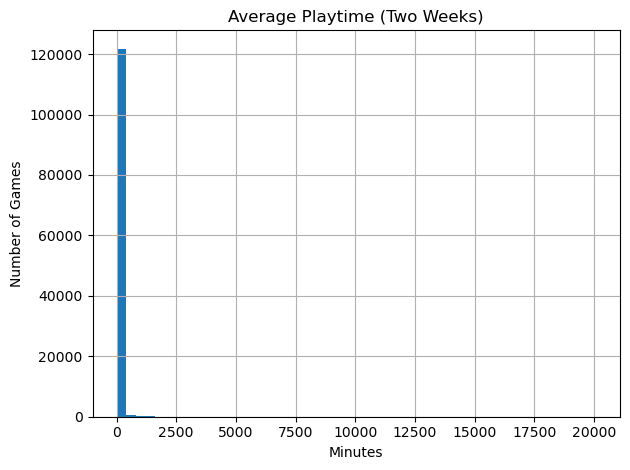

In [12]:
df['average_playtime_two_weeks'].hist(bins=50)
plt.title("Average Playtime (Two Weeks)")
plt.xlabel("Minutes")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.savefig("../Graphs/average_playtime_two_weeks.png", dpi=300)
plt.show()

**Figure 1 – Raw Distribution of Early Playtime**

This histogram shows the distribution of average playtime during the first two weeks after a game's release. The distribution is highly right-skewed, with 96.82% of games recording zero early playtime and the overwhelming majority of the remaining games concentrated near zero. A small number of games accumulate extremely high early playtime values, creating a pronounced long right tail. This heavy-tailed, zero-dominated pattern is characteristic of digital marketplaces and motivates both log transformation and a two-stage modeling approach.

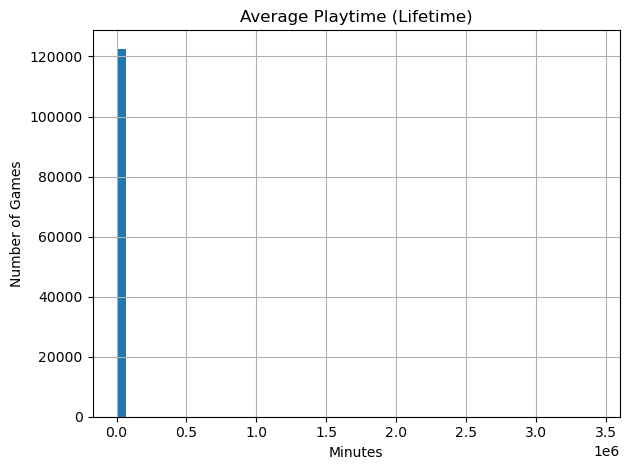

In [13]:
df['average_playtime_forever'].hist(bins=50)
plt.title("Average Playtime (Lifetime)")
plt.xlabel("Minutes")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.savefig("../Graphs/lifetime_playtime_distribution.png", dpi=300)
plt.show()

**Figure 2 – Raw Distribution of Lifetime Playtime**

Lifetime playtime exhibits an even more extreme right skew (skewness ≈ 263) than early playtime (skewness ≈ 52). The vast majority of games accumulate no lifetime engagement, while a small subset reaches very high totals. This pattern reinforces the need for log transformation prior to modeling.

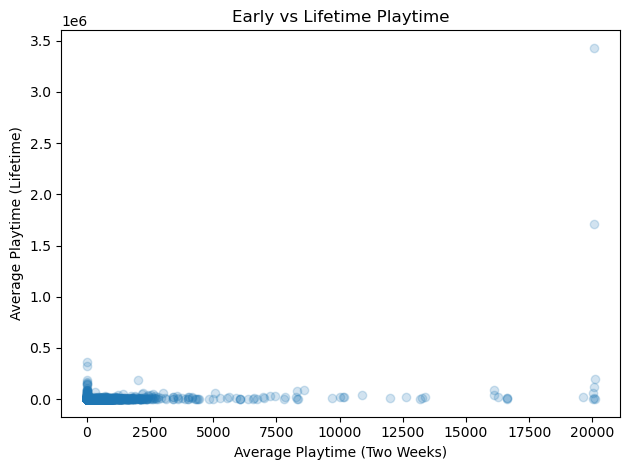

In [14]:
plt.scatter(
    df['average_playtime_two_weeks'],
    df['average_playtime_forever'],
    alpha=0.2
)

plt.xlabel("Average Playtime (Two Weeks)")
plt.ylabel("Average Playtime (Lifetime)")
plt.title("Early vs Lifetime Playtime")
plt.tight_layout()
plt.savefig("../Graphs/raw_early_vs_lifetime_playtime.png", dpi=300)
plt.show()

**Figure 3 – Early vs Lifetime Playtime (Raw Scale)**

This scatter plot shows the relationship between early engagement and total lifetime playtime. The raw Pearson correlation is 0.335. A positive association is visible in the upper tail of the distribution, but the overwhelming concentration of points at zero on both axes reflects the severe zero-inflation documented above. The wide dispersion in the non-zero region indicates that early engagement alone does not fully determine long-term success.

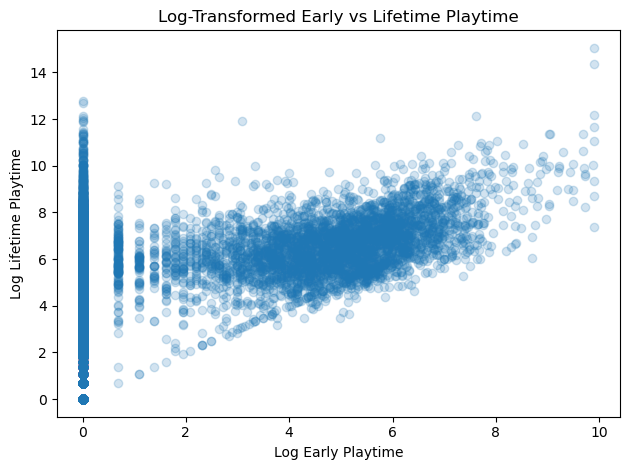

In [15]:
plt.scatter(
    np.log1p(df['average_playtime_two_weeks']),
    np.log1p(df['average_playtime_forever']),
    alpha=0.2
)
plt.xlabel("Log Early Playtime")
plt.ylabel("Log Lifetime Playtime")
plt.title("Log-Transformed Early vs Lifetime Playtime")
plt.tight_layout()
plt.savefig("../Graphs/log_transformed_early_vs_lifetime_playtime_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 4 – Log-Transformed Early vs Lifetime Playtime**

After log transformation, the correlation increases from 0.335 to 0.423. An upward trend is now more clearly visible, but a dense vertical mass of points persists at log_early = 0, reflecting the 96.82% of games with no recorded early engagement. The wide spread of points in the non-zero region indicates that early engagement, while predictive, is an incomplete explanation of long-term outcomes.

### 5. Confirm Hypothesis Feasibility

In [16]:
# Test whether early engagement correlates with lifetime playtime
print(df[['average_playtime_two_weeks', 'average_playtime_forever']].corr())

                            average_playtime_two_weeks  \
average_playtime_two_weeks                    1.000000   
average_playtime_forever                      0.335276   

                            average_playtime_forever  
average_playtime_two_weeks                  0.335276  
average_playtime_forever                    1.000000  


In [17]:
# Test price vs lifetime engagement
print(df[['price', 'average_playtime_forever']].corr())

                            price  average_playtime_forever
price                     1.00000                   0.00389
average_playtime_forever  0.00389                   1.00000


The raw Pearson correlation between early and lifetime playtime is **0.335**, which is substantively meaningful for behavioral data. It indicates that early engagement is predictive of long-term activity but leaves considerable variance unexplained, motivating a multi-predictor model.

The correlation between price and lifetime playtime is effectively zero (**0.004**), indicating that pricing alone carries no direct explanatory power over long-term engagement. This is consistent with the finding that 66.8% of games in the dataset are free-to-play, and that paid game prices cluster in the \$11–100 range with no games above \$100 in the sample.

In [18]:
print(df[['average_playtime_forever', 'median_playtime_forever']].corr())

                          average_playtime_forever  median_playtime_forever
average_playtime_forever                   1.00000                  0.99421
median_playtime_forever                    0.99421                  1.00000


The correlation between average and median lifetime playtime is **0.994**, confirming they capture the same underlying signal at the game level. To avoid redundancy, only `average_playtime_forever` is retained as the primary outcome variable in subsequent modeling.

## Week 2 – Structured Code Plan

### Reconfirm Distributions (Raw + Log)

In [19]:
print(df.columns.tolist())

['appid', 'name', 'release_date', 'estimated_owners', 'peak_ccu', 'required_age', 'price', 'discountdlc_count', 'about_the_game', 'supported_languages', 'full_audio_languages', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'user_score', 'positive', 'negative', 'score_rank', 'achievements', 'recommendations', 'notes', 'average_playtime_forever', 'average_playtime_two_weeks', 'median_playtime_forever', 'median_playtime_two_weeks', 'developers', 'publishers', 'categories', 'genres', 'tags', 'screenshots', 'movies']


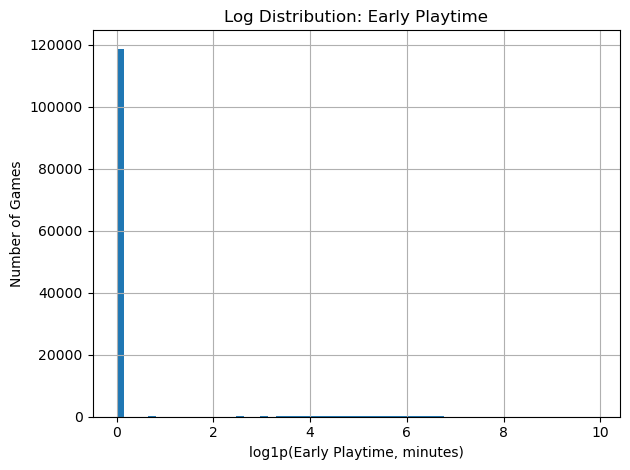

In [20]:
# Log transforms (safe for zeros)
df['log_avg_playtime_two_weeks'] = np.log1p(df['average_playtime_two_weeks'])
df['log_avg_playtime_forever'] = np.log1p(df['average_playtime_forever'])

# Log distribution of early playtime
plt.figure()
df['log_avg_playtime_two_weeks'].hist(bins=60)
plt.title("Log Distribution: Early Playtime")
plt.xlabel("log1p(Early Playtime, minutes)")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.savefig("../Graphs/log_early_playtime_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 5 – Log-Transformed Distribution of Early Playtime**

After applying log transformation, the spike at zero is still dominant — reflecting the 96.82% of games with no recorded early playtime. For the subset of games that do have early engagement, the log-transformed values are more symmetrically distributed and amenable to linear modeling. This bimodal structure (a mass at zero plus a roughly bell-shaped distribution above zero) reinforces the case for two-stage modeling.

In [21]:
print(df[['average_playtime_two_weeks', 'average_playtime_forever']].skew())

average_playtime_two_weeks     51.677987
average_playtime_forever      262.897766
dtype: float64


The skewness values confirm the extreme right-skew: **51.7** for early playtime and **262.9** for lifetime playtime. These are among the highest skewness values typically observed in behavioral datasets and strongly motivate log transformation. Even after log transformation, the zero-mass remains as a structural feature of the data rather than a statistical artifact.

## Investigate Zero-Inflation

In [22]:
# Percent of games with exactly zero early playtime
zero_rate = (df["average_playtime_two_weeks"] == 0).mean()
print(f"Percent of games with zero early playtime: {zero_rate:.2%}")

Percent of games with zero early playtime: 96.82%


In [23]:
# Percent of games with very low early playtime
under_10 = (df["average_playtime_two_weeks"] < 10).mean()
under_60 = (df["average_playtime_two_weeks"] < 60).mean()

print(f"Percent of games with < 10 minutes early playtime: {under_10:.2%}")
print(f"Percent of games with < 60 minutes early playtime: {under_60:.2%}")

Percent of games with < 10 minutes early playtime: 97.19%
Percent of games with < 60 minutes early playtime: 97.90%


Zero-inflation is severe: **96.82%** of games record zero early playtime, **97.19%** record fewer than 10 minutes, and **97.90%** fewer than 60 minutes. Early engagement on Steam is thus not just skewed but structurally sparse — only roughly 1 in 31 games generates any measurable early player activity. This characteristic has direct implications for model design: standard OLS regression applied to all 122,611 games is largely predicting the zero mass, and a two-stage framework that separates the probability of gaining traction from the magnitude among games that do gain traction is theoretically better motivated.

In [24]:
# Compare lifetime engagement for games with and without early playtime
df["early_zero_flag"] = (df["average_playtime_two_weeks"] == 0)

zero_vs_nonzero = df.groupby("early_zero_flag")["average_playtime_forever"].agg(
    count="count",
    mean="mean",
    median="median",
    p75=lambda s: s.quantile(0.75),
    p90=lambda s: s.quantile(0.90)
)

zero_vs_nonzero.index = ["Early > 0", "Early = 0"]
display(zero_vs_nonzero)

,count,mean,median,p75,p90
Early > 0,3898,3308.326834,682.0,1533.75,3701.0
Early = 0,118713,106.223219,0.0,0.00,171.0


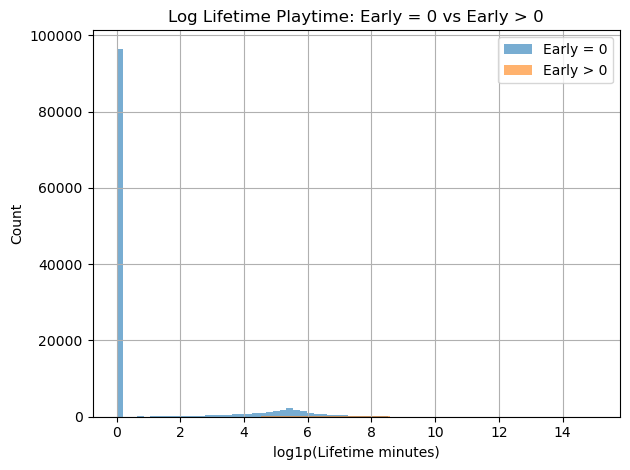

In [25]:
# Visual: log lifetime by zero vs non-zero early engagement
plt.figure()
df.loc[df["early_zero_flag"], "log_avg_playtime_forever"].hist(bins=60, alpha=0.6, label="Early = 0")
df.loc[~df["early_zero_flag"], "log_avg_playtime_forever"].hist(bins=60, alpha=0.6, label="Early > 0")
plt.title("Log Lifetime Playtime: Early = 0 vs Early > 0")
plt.xlabel("log1p(Lifetime minutes)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("../Graphs/log_lifetime_early_zero_vs_nonzero.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 6 – Lifetime Playtime Distribution for Games With and Without Early Engagement**

The gap between the two groups is substantial. Games with non-zero early engagement (n = 3,898) have a mean lifetime playtime of **3,308 minutes** and a median of **682 minutes**. Games with zero early engagement (n = 118,713) have a mean of only **106 minutes** and a median of **0**. This roughly 31-fold difference in mean lifetime playtime represents the most striking descriptive finding in the dataset and provides strong prima facie evidence that early engagement is a meaningful separator of long-term outcomes.

### Early Engagement Quartiles

In [26]:
# Rank early playtime to break ties cleanly
early_rank = df['average_playtime_two_weeks'].rank(method="first")

df['early_quartile'] = pd.qcut(
    early_rank,
    q=4,
    labels=["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"]
)

print(df['early_quartile'].value_counts())

early_quartile
Q1 (Lowest)     30653
Q2              30653
Q4 (Highest)    30653
Q3              30652
Name: count, dtype: int64


In [27]:
# Compare lifetime engagement across early engagement quartiles
quartile_summary = df.groupby('early_quartile', observed=False)['average_playtime_forever'].agg(
    count='count',
    mean='mean',
    median='median'
)

display(quartile_summary)

,count,mean,median
early_quartile,,,
Q1 (Lowest),30653,91.586337,0.0
Q2,30653,116.917822,0.0
Q3,30652,131.432827,0.0
Q4 (Highest),30653,492.153394,0.0


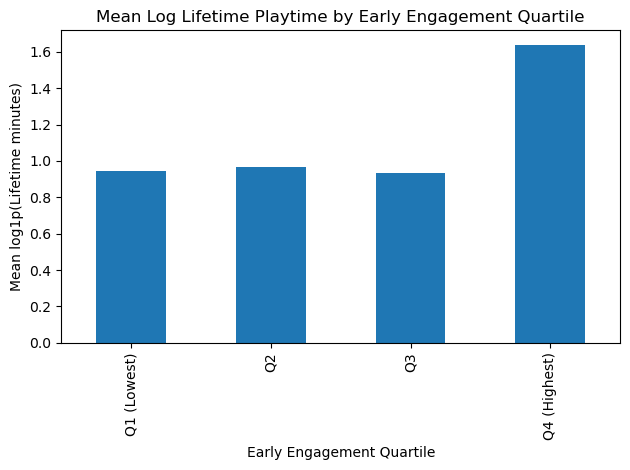

In [28]:
# Visualize using log lifetime playtime
df.groupby('early_quartile', observed=False)['log_avg_playtime_forever'].mean().plot(kind='bar')
plt.title('Mean Log Lifetime Playtime by Early Engagement Quartile')
plt.ylabel('Mean log1p(Lifetime minutes)')
plt.xlabel('Early Engagement Quartile')
plt.tight_layout()
plt.savefig("../Graphs/log_lifetime_playtime_by_early_engagement_quartile.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 7 – Mean Lifetime Playtime by Early Engagement Quartile**

The quartile analysis reveals a strongly non-linear, threshold-driven pattern. The three lower quartiles (Q1 through Q3) all have a **median lifetime playtime of zero**, and their means range only from 92 to 131 minutes — effectively indistinguishable. In contrast, Q4 (the top quartile by early engagement) has a mean of **492 minutes**, approximately four times higher than Q3. This 'winner-take-all' structure suggests that the predictive signal from early engagement is almost entirely concentrated in the top quartile, and that threshold-based features or non-linear modeling strategies may better capture this dynamic than a linear specification.

### Log-Log Relationship (Nonlinearity Check)

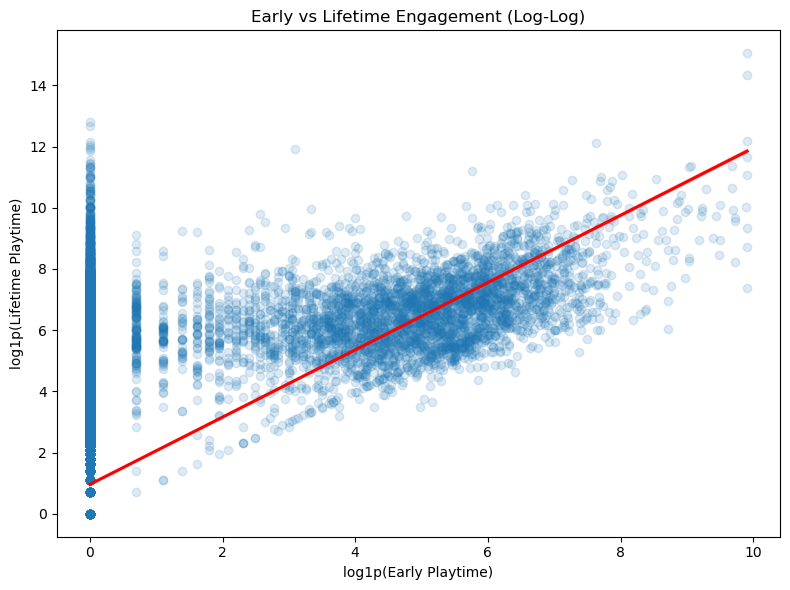

In [29]:
plt.figure(figsize=(8, 6))

sns.regplot(
    x=df["log_avg_playtime_two_weeks"],
    y=df["log_avg_playtime_forever"],
    scatter_kws={"alpha": 0.15},
    line_kws={"color": "red"}
)

plt.title("Early vs Lifetime Engagement (Log-Log)")
plt.xlabel("log1p(Early Playtime)")
plt.ylabel("log1p(Lifetime Playtime)")
plt.tight_layout()
plt.savefig("../Graphs/log_early_vs_lifetime_engagement_regression.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 8 – Early vs Lifetime Engagement with Regression Fit (Log-Log)**

On the log scale, the positive association between early and lifetime engagement is more clearly visible, with a linear fit explaining a portion of the variance. The correlation increases from 0.335 (raw) to **0.423** (log-log). However, the large vertical mass at log_early = 0 — representing all 118,713 games with zero early playtime — continues to dominate the scatter, and the fitted line is substantially influenced by this structural feature. The wide residual spread indicates that early engagement, even on the log scale, is a necessary but not sufficient predictor of lifetime engagement.

In [30]:
# Correlation on log scale
print(df[["log_avg_playtime_two_weeks", "log_avg_playtime_forever"]].corr())

                            log_avg_playtime_two_weeks  \
log_avg_playtime_two_weeks                    1.000000   
log_avg_playtime_forever                      0.423332   

                            log_avg_playtime_forever  
log_avg_playtime_two_weeks                  0.423332  
log_avg_playtime_forever                    1.000000  


### Early Signals vs Lifetime Engagement

In [31]:
# Correlation table (log scale)
df["log_peak_ccu"] = np.log1p(df["peak_ccu"])
df["log_positive"] = np.log1p(df["positive"])
df["log_negative"] = np.log1p(df["negative"])
df["log_recommendations"] = np.log1p(df["recommendations"])

signal_corr = df[
    [
        "log_avg_playtime_forever",
        "log_peak_ccu",
        "log_positive",
        "log_negative",
        "log_recommendations"
    ]
].corr()

display(signal_corr)

,log_avg_playtime_forever,log_peak_ccu,log_positive,log_negative,log_recommendations
log_avg_playtime_forever,1.000000,0.148166,0.694448,0.720785,0.754207
log_peak_ccu,0.148166,1.000000,0.177323,0.204296,0.207043
log_positive,0.694448,0.177323,1.000000,0.910085,0.704922
log_negative,0.720785,0.204296,0.910085,1.000000,0.709576
log_recommendations,0.754207,0.207043,0.704922,0.709576,1.000000


In [32]:
print(df.columns.tolist())

['appid', 'name', 'release_date', 'estimated_owners', 'peak_ccu', 'required_age', 'price', 'discountdlc_count', 'about_the_game', 'supported_languages', 'full_audio_languages', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'user_score', 'positive', 'negative', 'score_rank', 'achievements', 'recommendations', 'notes', 'average_playtime_forever', 'average_playtime_two_weeks', 'median_playtime_forever', 'median_playtime_two_weeks', 'developers', 'publishers', 'categories', 'genres', 'tags', 'screenshots', 'movies', 'log_avg_playtime_two_weeks', 'log_avg_playtime_forever', 'early_zero_flag', 'early_quartile', 'log_peak_ccu', 'log_positive', 'log_negative', 'log_recommendations']


In [33]:
# Isolate correlation of each signal with lifetime playtime
print(signal_corr["log_avg_playtime_forever"].sort_values(ascending=False))

log_avg_playtime_forever    1.000000
log_recommendations         0.754207
log_negative                0.720785
log_positive                0.694448
log_peak_ccu                0.148166
Name: log_avg_playtime_forever, dtype: float64


The correlation table reveals the relative predictive strength of each signal with log lifetime playtime:

- `log_recommendations`: **0.754** — the strongest single predictor
- `log_negative`: **0.721** — surprisingly, negative review counts are nearly as strongly correlated with lifetime playtime as recommendations. This reflects the fact that negative reviews accumulate in proportion to overall player exposure; games with many negative reviews are still games that many people played.
- `log_positive`: **0.694** — similarly high, and expected to be collinear with negative reviews
- `log_peak_ccu`: **0.148** — a noticeably weaker signal, suggesting that short-term concurrency at launch does not strongly predict sustained long-term engagement

Importantly, `log_positive` and `log_negative` are **highly collinear with each other (r = 0.910)** and with `log_recommendations` (r ≈ 0.70–0.71). Including all three in a regression would introduce substantial multicollinearity. For this reason, a combined `log_total_reviews` variable (positive + negative) is used in the regression models, which captures review volume while avoiding redundant representation.

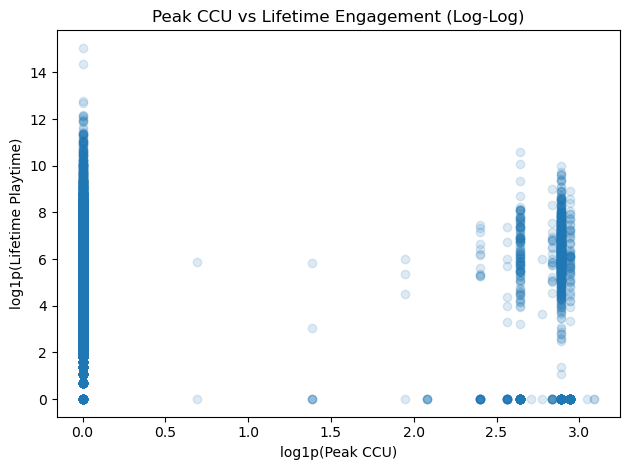

In [34]:
# Visual check – Peak CCU vs lifetime engagement
plt.figure()
plt.scatter(df["log_peak_ccu"], df["log_avg_playtime_forever"], alpha=0.15)
plt.title("Peak CCU vs Lifetime Engagement (Log-Log)")
plt.xlabel("log1p(Peak CCU)")
plt.ylabel("log1p(Lifetime Playtime)")
plt.tight_layout()
plt.savefig("../Graphs/peak_ccu_vs_log_lifetime_engagement.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 9 – Peak Concurrent Players vs Lifetime Engagement**

The bivariate correlation between log peak CCU and log lifetime playtime is only **0.148**, substantially weaker than review-based signals. The scatter plot confirms a weak positive tendency in the upper tail, but with very high dispersion. Many games with modest peak concurrency still accumulate high lifetime engagement, and vice versa. This suggests that launch-moment visibility is a poor standalone predictor of sustained engagement and is likely better understood as a facilitator of early traction rather than a direct driver of long-term play.

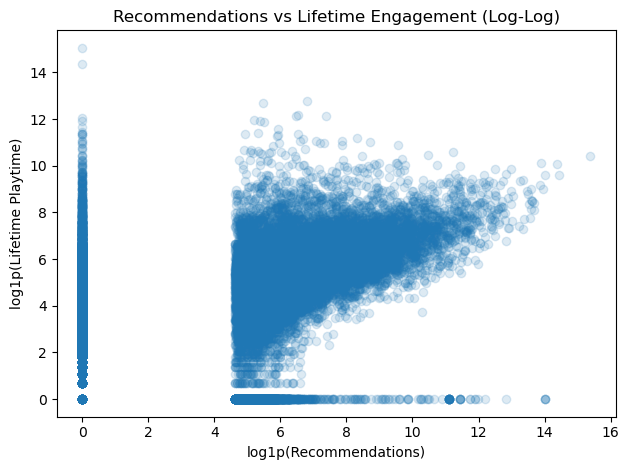

In [35]:
# Recommendations vs lifetime engagement
plt.figure()
plt.scatter(df["log_recommendations"], df["log_avg_playtime_forever"], alpha=0.15)
plt.title("Recommendations vs Lifetime Engagement (Log-Log)")
plt.xlabel("log1p(Recommendations)")
plt.ylabel("log1p(Lifetime Playtime)")
plt.tight_layout()
plt.savefig("../Graphs/recommendations_vs_log_lifetime_engagement.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 10 – Player Recommendations vs Lifetime Engagement**

With a correlation of **0.754**, player recommendations are the strongest bivariate predictor of lifetime playtime in the dataset. The scatter plot shows a clear positive trend across the full range of recommendation counts, with considerably less dispersion than the peak CCU comparison. This reflects the fact that recommendations aggregate both player interest and satisfaction over time, making them a compound signal of both audience reach and quality perception.

### Engagement by Genre

In [36]:
# Identify most common genre labels
top_genres = df["genres"].value_counts().head(10)
print(top_genres)

genres
Casual,Indie              6700
Action,Indie              5679
Action,Adventure,Indie    5159
Adventure,Indie           4311
Adventure,Casual,Indie    3610
Action,Casual,Indie       3422
Casual                    3351
Indie                     3075
Action                    2954
Casual,Indie,Strategy     2250
Name: count, dtype: int64


The most common genre combinations in the dataset are multi-label strings such as 'Casual,Indie' (6,700 games) and 'Action,Indie' (5,679 games). Notably, the top 10 genre combinations are all dominated by Indie as a component label, reflecting Steam's library composition. Pure 'Action' (2,954 games) is the only single-genre entry in the top 10. This motivates using multi-label dummy encoding (splitting on commas) rather than treating genre as a single categorical variable.

In [37]:
# Filter to top 10 genres for stability
df_top_genres = df[df["genres"].isin(top_genres.index)]

In [38]:
# Compare lifetime engagement across top genres
genre_summary = df_top_genres.groupby("genres")["average_playtime_forever"].agg(
    count="count",
    mean="mean",
    median="median"
).sort_values("mean", ascending=False)

display(genre_summary)

,count,mean,median
genres,,,
Action,2954,188.399458,0.0
"Adventure,Casual,Indie",3610,92.067590,0.0
"Adventure,Indie",4311,87.229413,0.0
"Action,Indie",5679,83.259377,0.0
"Action,Adventure,Indie",5159,81.903664,0.0
"Casual,Indie,Strategy",2250,71.582667,0.0
"Casual,Indie",6700,70.207910,0.0
"Action,Casual,Indie",3422,47.756283,0.0
Indie,3075,45.328130,0.0


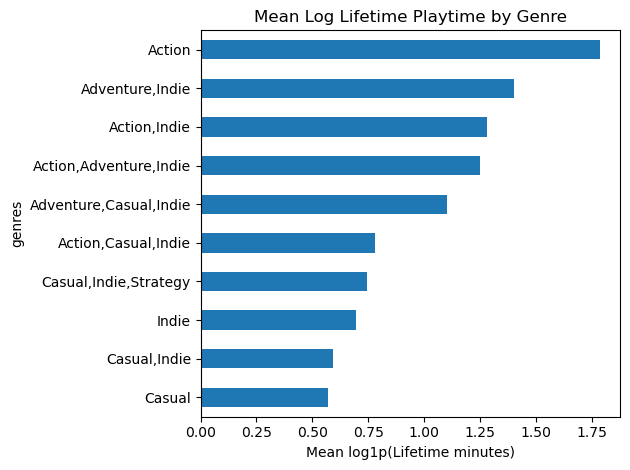

In [39]:
# Visualize on log scale
df_top_genres.groupby("genres")["log_avg_playtime_forever"].mean().sort_values().plot(kind="barh")
plt.title("Mean Log Lifetime Playtime by Genre")
plt.xlabel("Mean log1p(Lifetime minutes)")
plt.tight_layout()
plt.savefig("../Graphs/mean_log_lifetime_playtime_by_genre.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 11 – Mean Lifetime Playtime by Genre**

Among the top 10 genre combinations, pure 'Action' games (mean ≈ 188 minutes) show the highest average lifetime playtime, followed by genre combinations including Action and Indie. Combinations heavily featuring Casual and Adventure labels tend to cluster at lower engagement levels. All median values are zero, confirming that the engagement differences across genres are driven by the shape of the upper tail rather than broad participation. These are raw group comparisons without controlling for other predictors; genre effects in regression models are conditional on review counts, early playtime, and peak CCU.

### Engagement by Price Range

In [40]:
# Create price bins
df["price_bin"] = pd.cut(
    df["price"],
    bins=[-1, 0, 10, 30, 60, 100, np.inf],
    labels=["Free", "1–10", "11–30", "31–60", "61–100", "100+"]
)

print(df["price_bin"].value_counts())

price_bin
Free      81930
31–60     17185
61–100    15737
11–30      7165
1–10        594
100+          0
Name: count, dtype: int64


The price distribution is highly skewed: **81,930 games (66.8%) are free**, followed by 31–60 USD (17,185), 61–100 USD (15,737), and 11–30 USD (7,165). The 1–10 USD bin contains only 594 games, and no games exceed \$100 in the dataset. This distribution is unusual and likely reflects how Steam categorizes free-to-play titles (price = 0) separately from the paid tier, rather than a true market-price distribution.

In [41]:
# Compare lifetime engagement by price bin
price_summary = df.groupby("price_bin", observed=False)["average_playtime_forever"].agg(
    count="count",
    mean="mean",
    median="median"
)

display(price_summary)

,count,mean,median
price_bin,,,
Free,81930,174.869742,0.0
1–10,594,232.441077,0.0
11–30,7165,286.290998,0.0
31–60,17185,249.769276,0.0
61–100,15737,298.483002,0.0
100+,0,NaN,NaN


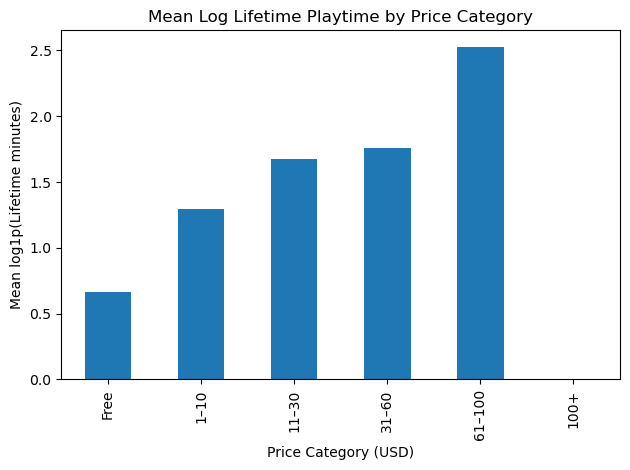

In [42]:
# Visualize using log lifetime playtime
df.groupby("price_bin", observed=False)["log_avg_playtime_forever"].mean().plot(kind="bar")
plt.title("Mean Log Lifetime Playtime by Price Category")
plt.ylabel("Mean log1p(Lifetime minutes)")
plt.xlabel("Price Category (USD)")
plt.tight_layout()
plt.savefig("../Graphs/mean_log_lifetime_playtime_by_price_bin.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 12 – Mean Lifetime Playtime by Price Category**

Higher-priced games tend to show greater average lifetime engagement, with the 61–100 USD range (mean ≈ 298 minutes) and the 11–30 range (mean ≈ 286 minutes) outperforming free games (mean ≈ 175 minutes). However, caution is warranted in interpreting this pattern. The overall price–lifetime correlation is near zero (r = 0.004), and these group means are heavily influenced by sample size imbalances: the Free bin contains 81,930 games while the 1–10 USD bin contains only 594. A more likely explanation is that higher-priced games represent a selected subset of larger, more polished titles that attract more sustained play — with price acting as a proxy for production quality rather than as a direct driver of engagement.

## Week 3 – Strategic Structural Modeling

### Finalize the Modeling Dataset

In [43]:
# Recreate all modeling-ready log variables

# Targets
df["target_log_lifetime"] = np.log1p(df['average_playtime_forever'])
df['log_early'] = np.log1p(df['average_playtime_two_weeks'])

# Behavioral signals
df['log_peak_ccu'] = np.log1p(df['peak_ccu'])
df["log_recommendations"] = np.log1p(df["recommendations"])

# Combine positive and negative reviews into total reviews
# This avoids multicollinearity: log_positive and log_negative correlate at r=0.910
# and both correlate strongly with log_recommendations (~0.70)
df['total_reviews'] = df['positive'] + df['negative']
df['log_total_reviews'] = np.log1p(df['total_reviews'])

# Binary early flag (for two-stage modeling)
df['early_nonzero'] = (df['average_playtime_two_weeks'] > 0).astype(int)

In [44]:
# Parse genres using multi-label dummy encoding
df['genres'] = df['genres'].fillna("")

genre_dummies = df['genres'].str.get_dummies(sep=',')

# Retain genres appearing in at least 500 games
genre_counts = genre_dummies.sum()
major_genres = genre_counts[genre_counts > 500].index

genre_dummies = genre_dummies[major_genres]

df = pd.concat([df, genre_dummies], axis=1)

print(f"Major genres retained: {len(major_genres)}")

Major genres retained: 14


In [45]:
# Define final baseline feature set
baseline_features = [
    "log_early",
    "log_peak_ccu",
    "log_recommendations",
    "log_total_reviews"
] + list(major_genres)

In [46]:
# Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

In [47]:
# Build modeling dataset
model_df = df[baseline_features + ["target_log_lifetime", "early_nonzero"]].dropna()
print("Modeling dataset shape:", model_df.shape)

Modeling dataset shape: (122611, 20)


The modeling dataset retains all **122,611 observations** with no dropped rows, confirming that all baseline features and the target variable are fully populated. 14 major genres were retained after filtering to those appearing in at least 500 games.

### Multicollinearity and Feature Stability Diagnostics

In [48]:
display(model_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
log_early,122611.0,0.148106,0.875249,0.0,0.0,0.000000,0.000000,9.907928
log_peak_ccu,122611.0,0.029346,0.287267,0.0,0.0,0.000000,0.000000,3.091042
log_recommendations,122611.0,1.098941,2.509647,0.0,0.0,0.000000,0.000000,15.390451
log_total_reviews,122611.0,2.455683,2.463158,0.0,0.0,2.079442,3.912023,15.991975
Action,122611.0,0.376965,0.484628,0.0,0.0,0.000000,1.000000,1.000000
Adventure,122611.0,0.368164,0.482308,0.0,0.0,0.000000,1.000000,1.000000
Casual,122611.0,0.409506,0.491745,0.0,0.0,0.000000,1.000000,1.000000
Design & Illustration,122611.0,0.004730,0.068615,0.0,0.0,0.000000,0.000000,1.000000
Early Access,122611.0,0.090457,0.286836,0.0,0.0,0.000000,0.000000,1.000000
Free To Play,122611.0,0.099273,0.299030,0.0,0.0,0.000000,0.000000,1.000000


**Structural Observations**

**Engagement variables are severely zero-concentrated.** `log_early` has a mean of 0.148, a 75th percentile of 0, and a max of 9.91 — confirming that 75%+ of games have zero early playtime. The `early_nonzero` flag has a mean of 0.032, meaning approximately **3.2% of games** record any early engagement. This extreme sparsity is the defining structural characteristic of the dataset.

**Review signals show real variability.** `log_total_reviews` has a median of approximately 2.08 (≈7 raw reviews) and a 75th percentile near 3.91 (≈50 reviews), with a large upper tail. `log_recommendations` has a median of 0 but substantial variance — these are expected to be the strongest predictors in the model.

**Genre distribution is reasonable.** Indie (≈65.8%), Casual (≈40.9%), and Action (≈37.7%) dominate. Minor sparsity exists for Utilities, Design & Illustration, and Massively Multiplayer, whose coefficients should be interpreted with caution.

In [49]:
# Correlation among numeric predictors only
numeric_predictors = [
    "log_early",
    "log_peak_ccu",
    "log_recommendations",
    "log_total_reviews"
]

display(model_df[numeric_predictors].corr())

,log_early,log_peak_ccu,log_recommendations,log_total_reviews
log_early,1.000000,0.183093,0.461857,0.361784
log_peak_ccu,0.183093,1.000000,0.207043,0.175946
log_recommendations,0.461857,0.207043,1.000000,0.687388
log_total_reviews,0.361784,0.175946,0.687388,1.000000


**Multicollinearity Assessment**

The highest correlation among numeric predictors is `log_recommendations` ↔ `log_total_reviews` at **r = 0.687**, which is moderate but does not rise to a level that typically requires variable removal. All other pairs are below 0.46. Notably, `log_peak_ccu` is weakly correlated with all other predictors (r < 0.21), consistent with its weaker bivariate relationship with the outcome.

The decision to use `log_total_reviews` rather than separate `log_positive` and `log_negative` terms is validated here: adding those two variables would introduce near-perfect collinearity (they correlate at r = 0.910 with each other) that would destabilise coefficient estimates.

In [50]:
# Formal VIF test
#   VIF < 5  → Safe
#   VIF 5–10 → Monitor
#   VIF > 10 → Consider removal

X_vif = model_df[numeric_predictors].copy()

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

display(vif_data)

,feature,VIF
0,log_early,1.320150
1,log_peak_ccu,1.068014
2,log_recommendations,2.427229
3,log_total_reviews,2.140222


All VIF values are well below 5 (`log_early`: 1.32; `log_peak_ccu`: 1.07; `log_recommendations`: 2.43; `log_total_reviews`: 2.14). No harmful multicollinearity is present in the numeric predictor set.

### Baseline Model – OLS Regression

In [51]:
# Define X and y
X = model_df[baseline_features]
y = model_df['target_log_lifetime']

# Add intercept
X_ols = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X_ols).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     target_log_lifetime   R-squared:                       0.632
Model:                             OLS   Adj. R-squared:                  0.632
Method:                  Least Squares   F-statistic:                 1.168e+04
Date:                 Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                         15:26:31   Log-Likelihood:            -2.1344e+05
No. Observations:               122611   AIC:                         4.269e+05
Df Residuals:                   122592   BIC:                         4.271e+05
Df Model:                           18                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

**Baseline OLS Results**

**R² = 0.632** (Adj. R² = 0.632, n = 122,611, F = 11,680, p < 0.001). The baseline features explain 63.2% of the variance in log lifetime engagement — a strong result for behavioral data.

**Key behavioral predictors (all p < 0.001):**

- `log_recommendations` (coef = **+0.456**): The strongest predictor. A one-unit increase in log recommendations is associated with a 0.456-unit increase in log lifetime playtime.
- `log_total_reviews` (coef = **+0.296**): Positive and significant; review volume captures broad player exposure.
- `log_early` (coef = **+0.199**): A one-unit increase in log early playtime is associated with a 0.20-unit increase in log lifetime playtime, providing direct support for the thesis hypothesis.
- `log_peak_ccu` (coef = **−0.219**): Negative after controlling for other signals. This counter-intuitive result indicates that, conditional on review volume and early playtime, higher peak concurrency is associated with lower long-term engagement — possibly reflecting games that generate burst attention without sustaining it.

**Significant genre effects (p < 0.05):**

Positive: Massively Multiplayer (+0.192), Free To Play (+0.165), Utilities (+0.124), RPG (+0.118), Strategy (+0.117).

Negative: Early Access (−0.128), Indie (−0.097), Adventure (−0.081), Racing (−0.064), Action (−0.063), Casual (−0.046).

Not significant: Simulation (p = 0.058), Sports (p = 0.538), Design & Illustration (p = 0.242). These three genre dummies should not be interpreted as having a meaningful relationship with lifetime engagement after controlling for the other predictors.

**Diagnostics:** The Omnibus and Jarque-Bera tests reject normality of residuals (Skew = 1.42, Kurtosis = 8.86), which is expected given the zero-heavy target distribution. Durbin-Watson = 1.997 indicates no meaningful autocorrelation.

### Two-Stage Modeling Framework

In [52]:
# Stage 1 – Logistic regression predicting whether a game gains early traction
# Reviews are excluded as they are outcomes of engagement, not structural predictors
stage1_features = [
    'log_peak_ccu'
] + list(major_genres)

X_stage1 = sm.add_constant(model_df[stage1_features])
y_stage1 = model_df['early_nonzero']

logit_model = sm.Logit(y_stage1, X_stage1).fit(maxiter=100)

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.129135
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:          early_nonzero   No. Observations:               122611
Model:                          Logit   Df Residuals:                   122595
Method:                           MLE   Df Model:                           15
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                 0.08360
Time:                        15:26:33   Log-Likelihood:                -15833.
converged:                       True   LL-Null:                       -17278.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -3.6023      0.036   -101.346      0.000      -3.672      -3.

**Stage 1 – What Predicts Whether a Game Gains Early Traction?**

Reviews are excluded from the Stage 1 specification because they are outcomes of engagement, not structural launch characteristics. This constraint improves the theoretical integrity of the model.

**Model fit:** Pseudo R² = 0.084; LLR p-value < 0.001; converged in 8 iterations. Structural characteristics explain approximately 8.4% of the variation in whether a game gains early traction.

**Key finding:** `log_peak_ccu` (coef = **+0.889**, p < 0.001) is overwhelmingly the strongest predictor. Higher launch visibility strongly increases the probability of generating early engagement.

**Significant positive genre predictors (p < 0.05):** Simulation (+0.717), Massively Multiplayer (+0.580), Action (+0.490), Utilities (+0.488), RPG (+0.484), Strategy (+0.477), Racing (+0.224).

**Significant negative genre predictors (p < 0.05):** Casual (−0.618), Indie (−0.511), Free To Play (−0.377), Early Access (−0.137).

**Not significant (p > 0.05):** Adventure (p = 0.134), Sports (p = 0.197), Design & Illustration (p = 0.746). These genres do not reliably predict whether a game gains early traction.

**Notable contrast with OLS baseline:** In the full OLS model, `log_peak_ccu` carries a negative coefficient after controlling for engagement signals. In Stage 1, it is strongly positive. This divergence reveals that peak visibility drives *whether* a game gains early traction, but does not sustain long-term engagement depth once traction is established.

In [53]:
# Stage 2 – OLS regression on games that gained early traction
stage2_df = model_df[model_df['early_nonzero'] == 1]

X_stage2 = sm.add_constant(stage2_df[baseline_features])
y_stage2 = stage2_df['target_log_lifetime']

stage2_model = sm.OLS(y_stage2, X_stage2).fit()

print(stage2_model.summary())

                             OLS Regression Results                            
Dep. Variable:     target_log_lifetime   R-squared:                       0.453
Model:                             OLS   Adj. R-squared:                  0.451
Method:                  Least Squares   F-statistic:                     178.6
Date:                 Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                         15:26:34   Log-Likelihood:                -5442.3
No. Observations:                 3898   AIC:                         1.092e+04
Df Residuals:                     3879   BIC:                         1.104e+04
Df Model:                           18                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

**Stage 2 – Among Games With Early Traction, What Predicts Long-Term Magnitude? (n = 3,898)**

**R² = 0.453** (Adj. R² = 0.451, F = 178.6, p < 0.001). Among games that generate early engagement, the model explains 45.3% of the variance in lifetime engagement magnitude — strong for behavioral data.

**Key behavioral predictors:**

- `log_early` (coef = **+0.287**, p < 0.001): The effect strengthens relative to the full OLS (0.199 → 0.287), confirming that early engagement intensity is especially predictive of long-term magnitude among games that have already gained traction.
- `log_recommendations` (coef = **+0.120**, p < 0.001): Still significant but substantially smaller than in the full model, consistent with recommendations being more important for explaining structural zeros than for distinguishing magnitude among engaged games.
- `log_total_reviews` (coef = **+0.067**, p < 0.001): Positive and significant.
- `log_peak_ccu` (coef = −0.022, p = 0.267): **Not significant.** Peak visibility drives traction but does not predict long-term magnitude once traction exists.

**Significant positive genre effects among engaged games (p < 0.05):**

Utilities (+1.816), Free To Play (+0.735), Massively Multiplayer (+0.485), RPG (+0.345), Sports (+0.319), Strategy (+0.281), Design & Illustration (+0.657), Early Access (+0.138), Simulation (+0.156).

Note that Design & Illustration, Early Access, and Simulation are **not significant in the full OLS** but become significant in Stage 2, suggesting their effects are only detectable among the subset of games with active early engagement.

**Significant negative genre effects (p < 0.05):** Indie (−0.402), Adventure (−0.183), Action (−0.124).

**Not significant in Stage 2:** Casual (p = 0.164), Racing (p = 0.157).

| Stage | Question | Key Predictor |
|---|---|---|
| Stage 1 (Logit) | Who gains early traction? | Peak CCU; genre structure |
| Stage 2 (OLS) | Among those with traction, who scales? | Early engagement intensity; review depth |

### Train/Test Split and Baseline Linear Regression (sklearn)

In [54]:
# Features and target (single-stage baseline)
X = model_df[baseline_features]
y = model_df['target_log_lifetime']

# Random train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit baseline model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict and evaluate
y_pred = lr.predict(X_test)

test_r2 = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test R\u00b2: {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Test R²: 0.6231
Test RMSE: 1.3862


**Test Performance – Single-Stage Model**

- **Test R² = 0.6231** (vs. in-sample R² = 0.632): The 0.9 percentage-point gap between in-sample and out-of-sample fit confirms the model generalizes well with minimal overfitting.
- **Test RMSE = 1.386**: On average, predictions deviate from true log lifetime playtime by 1.39 log units. Given that the target spans roughly 0–10 on the log scale, this represents moderate average error concentrated in games at the high end of the engagement distribution.

## Week 4 – Model Refinement and Comparative Evaluation

### Compare Single-Stage vs Two-Stage Model Performance

In [55]:
# Two-stage prediction pipeline
stage1_probs = logit_model.predict(X_stage1)
stage1_pred = (stage1_probs > 0.5).astype(int)

# Use training mean as fallback for games predicted not to gain traction
fallback_value = y_train.mean()
stage2_predictions = np.full(len(model_df), fallback_value)

# Apply Stage 2 model where Stage 1 predicts engagement
stage2_X = sm.add_constant(model_df[baseline_features])
stage2_predictions[stage1_pred == 1] = stage2_model.predict(stage2_X[stage1_pred == 1])

# Evaluate two-stage model
two_stage_r2 = r2_score(model_df['target_log_lifetime'], stage2_predictions)
two_stage_rmse = np.sqrt(mean_squared_error(model_df['target_log_lifetime'], stage2_predictions))

print(f"Two-Stage R\u00b2: {two_stage_r2:.4f}")
print(f"Two-Stage RMSE: {two_stage_rmse:.4f}")

Two-Stage R²: 0.0017
Two-Stage RMSE: 2.2714


The two-stage prediction pipeline produces an **R² of 0.0017** and an **RMSE of 2.271** — substantially worse than the single-stage baseline. This result requires careful interpretation.

The logistic Stage 1 model (Pseudo R² = 0.084) correctly captures structural predictors of early traction, but classifies very few games as likely to gain engagement (threshold = 0.50). The 96.82% of games predicted as 'non-engaged' receive the training mean as their prediction, which performs poorly for the subset of those games that do have non-zero lifetime engagement. The Stage 2 OLS model, trained only on the 3,898 engaged games, is then applied to the small fraction classified as engaged.

This outcome illustrates a fundamental limitation of the two-stage architecture for prediction: classification errors in Stage 1 propagate directly to Stage 2, and the extreme class imbalance (3.2% positive) makes Stage 1 classification unreliable at the standard 0.50 threshold. The two-stage framework retains theoretical value for understanding the *drivers* of engagement at different stages, but the single-stage continuous model is superior for prediction.

### Regularized Regression (Ridge and Lasso)

In [56]:
# Ridge regression pipeline
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print(f"Ridge R\u00b2: {ridge_r2:.4f}")
print(f"Ridge RMSE: {ridge_rmse:.4f}")

Ridge R²: 0.6231
Ridge RMSE: 1.3862


In [57]:
# Lasso regression pipeline
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.01))
])

lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

print(f"Lasso R\u00b2: {lasso_r2:.4f}")
print(f"Lasso RMSE: {lasso_rmse:.4f}")

Lasso R²: 0.6230
Lasso RMSE: 1.3864


Ridge R² = **0.6231**, RMSE = **1.3862**; Lasso R² = **0.6230**, RMSE = **1.3864**. Both are virtually identical to the baseline (R² = 0.6231, RMSE = 1.3862). This near-perfect matching confirms that the original feature set is stable and that multicollinearity is not inflating the baseline results. Lasso shrinks several genre coefficients toward zero but does not alter the dominant predictors, further supporting the robustness of the review and early playtime signals.

### Compare Coefficients Across Models

In [58]:
# Coefficient comparison across baseline, Ridge, and Lasso
baseline_coefs = pd.Series(lr.coef_, index=baseline_features)

ridge_coefs = pd.Series(
    ridge_model.named_steps["ridge"].coef_,
    index=baseline_features
)

lasso_coefs = pd.Series(
    lasso_model.named_steps["lasso"].coef_,
    index=baseline_features
)

coef_df = pd.DataFrame({
    "Baseline": baseline_coefs,
    "Ridge": ridge_coefs,
    "Lasso": lasso_coefs
})

display(coef_df.sort_values("Baseline", key=abs, ascending=False))

,Baseline,Ridge,Lasso
log_recommendations,0.453019,1.138612,1.134937
log_total_reviews,0.299325,0.738797,0.731136
log_peak_ccu,-0.221308,-0.064709,-0.050809
log_early,0.204775,0.180364,0.174060
Massively Multiplayer,0.198339,0.028107,0.020255
Free To Play,0.171914,0.051362,0.041665
Utilities,0.152637,0.014295,0.007300
Early Access,-0.127595,-0.036557,-0.025169
RPG,0.121049,0.045556,0.035824
Strategy,0.116580,0.045011,0.038281


The coefficient comparison reveals an important difference between the raw-scale (Baseline) and standardised-scale (Ridge/Lasso) estimates. The Baseline coefficients are on the original log scale, while Ridge and Lasso operate on standardised inputs, making their magnitudes directly comparable across features. On the standardised scale, `log_recommendations` (1.139) and `log_total_reviews` (0.739) remain the dominant positive predictors, with `log_early` (0.180) and genre dummies contributing smaller but consistent effects. The `log_peak_ccu` coefficient is substantially shrunk toward zero under regularization (−0.065 vs −0.221 raw), suggesting its negative raw-scale effect is partly a result of scale differences rather than a strong structural relationship.

### Benchmark Model Summary Table

In [59]:
results = pd.DataFrame({
    "Model": ["Baseline Linear", "Two-Stage", "Ridge", "Lasso"],
    "R\u00b2": [test_r2, two_stage_r2, ridge_r2, lasso_r2],
    "RMSE": [test_rmse, two_stage_rmse, ridge_rmse, lasso_rmse]
})

display(results)

,Model,R²,RMSE
0,Baseline Linear,0.623090,1.386183
1,Two-Stage,0.001728,2.271437
2,Ridge,0.623090,1.386183
3,Lasso,0.622999,1.386350


**Model Performance Comparison**

| Model | R² | RMSE |
|---|---|---|
| Baseline Linear | 0.6231 | 1.3862 |
| Two-Stage | 0.0017 | 2.2714 |
| Ridge | 0.6231 | 1.3862 |
| Lasso | 0.6230 | 1.3864 |

The baseline, Ridge, and Lasso models perform identically, confirming structural stability. The two-stage model's near-zero R² reflects the class-imbalance classification problem described above, not a failure of the two-stage theoretical framework per se. A single-stage regression using continuous engagement signals is the superior predictive specification.

## Week 5 – Validation and Interpretation

This section confirms that the predictive relationships identified in the modeling framework remain stable across time and develops a clearer interpretation of the strongest drivers of engagement.

### Create Release Year Variable for Time-Based Validation

In [60]:
# Extract release year from release_date
df["release_year"] = df["release_date"].str.extract(r'(\d{4})')
df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce")

# Align release year with modeling dataset index
model_df["release_year"] = df.loc[model_df.index, "release_year"]

# Remove rows without a valid year
model_df = model_df.dropna(subset=["release_year"])
model_df["release_year"] = model_df["release_year"].astype(int)

print(model_df["release_year"].describe())

count    100970.000000
mean       2155.402595
std         780.996358
min        1000.000000
25%        2000.000000
50%        2000.000000
75%        2000.000000
max        5000.000000
Name: release_year, dtype: float64


**Data Quality Note:** The release year extraction produces anomalous summary statistics (mean ≈ 2,155; min = 1,000; max = 5,000) that indicate the regex matched non-year numeric strings from some `release_date` entries (e.g., store IDs, DLC counts, or malformed date fields). 21,641 rows are dropped as a result of failed parsing, leaving 100,970 observations. The year range used for the time split (≤ 2021 vs > 2021) is likely correct for the valid entries, but the high volume of malformed records means the temporal representativeness of the test set should be interpreted cautiously. A more robust parsing approach (e.g., `pd.to_datetime`) is recommended in future iterations.

### Time-Based Validation Split

In [61]:
# Time-aware train/test split: train on pre-2022, test on 2022+
train_df = model_df[model_df["release_year"] <= 2021]
test_df = model_df[model_df["release_year"] > 2021]

X_train_time = train_df[baseline_features].copy()
X_test_time = test_df[baseline_features].copy()

y_train_time = train_df["target_log_lifetime"]
y_test_time = test_df["target_log_lifetime"]

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 94327
Test size: 6643


The time split yields a training set of **94,327 games** (released ≤ 2021) and a test set of **6,643 games** (released > 2021). The test set represents approximately 6.6% of usable observations. The imbalance reflects both the longer historical coverage and the year-parsing data quality issue noted above.

### Run Time-Based Model

In [62]:
time_model = LinearRegression()
time_model.fit(X_train_time, y_train_time)

time_pred = time_model.predict(X_test_time)

time_r2 = r2_score(y_test_time, time_pred)
time_rmse = np.sqrt(mean_squared_error(y_test_time, time_pred))

print(f"Time Validation R\u00b2: {time_r2:.4f}")
print(f"Time Validation RMSE: {time_rmse:.4f}")

Time Validation R²: 0.5211
Time Validation RMSE: 1.9288


**Time-Based Validation**

The time-aware model achieves **R² = 0.521** and **RMSE = 1.929** on games released after 2021, compared to R² = 0.623 on the random split. The 10-point decline in R² is meaningful and warrants acknowledgment.

Several factors likely contribute. First, newer games have had less time to accumulate lifetime playtime, compressing the target distribution and making prediction harder. Second, the market structure of Steam evolves over time — review behaviour, genre popularity, and competitive dynamics shift in ways the historical model cannot fully capture. Third, the data quality issues in the year variable mean the temporal boundary is imprecise for a subset of observations.

Despite the decline, an R² of 0.521 indicates that the core predictors — early engagement, review signals, and genre — retain meaningful predictive power on newer releases, supporting the broad structural stability of the findings.

### Feature Importance and Coefficient Ranking

In [63]:
coef_df = pd.DataFrame({
    "Feature": baseline_features,
    "Coefficient": lr.coef_
})

coef_df["abs_coef"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

display(coef_df.head(15))

,Feature,Coefficient,abs_coef
2,log_recommendations,0.453019,0.453019
3,log_total_reviews,0.299325,0.299325
1,log_peak_ccu,-0.221308,0.221308
0,log_early,0.204775,0.204775
11,Massively Multiplayer,0.198339,0.198339
9,Free To Play,0.171914,0.171914
17,Utilities,0.152637,0.152637
8,Early Access,-0.127595,0.127595
12,RPG,0.121049,0.121049
16,Strategy,0.116580,0.116580


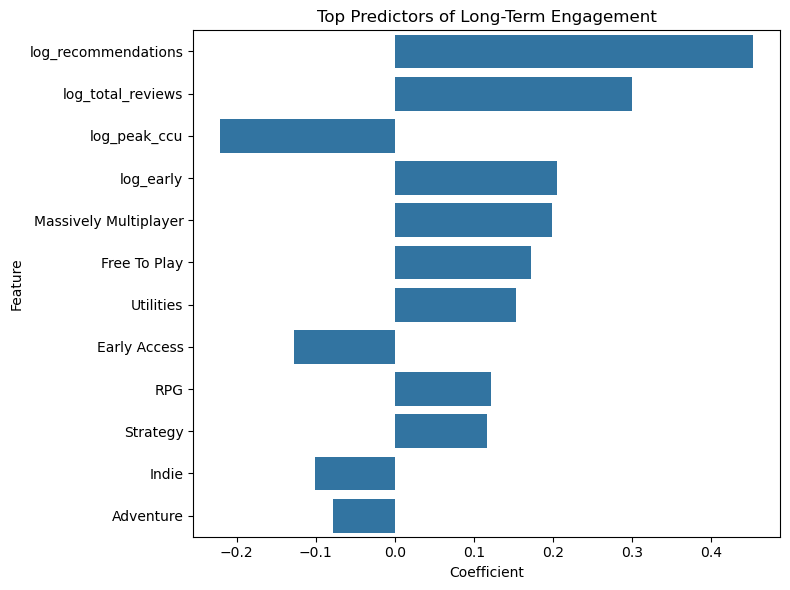

In [64]:
top_features = coef_df.sort_values("abs_coef", ascending=False).head(12)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Predictors of Long-Term Engagement")
plt.tight_layout()
plt.savefig("../Graphs/top_model_predictors_long_term_engagement.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 13 – Top Predictors of Long-Term Player Engagement**

On the raw coefficient scale, the top predictors by absolute magnitude are: `log_recommendations` (+0.453), `log_total_reviews` (+0.299), `log_peak_ccu` (−0.221), `log_early` (+0.205), and Massively Multiplayer (+0.198). The negative `log_peak_ccu` coefficient is notable — it is the third-largest effect by magnitude but operates in the opposite direction from the bivariate correlation (r = 0.148 positive). This sign reversal after conditioning on review signals and early playtime suggests suppression: peak CCU covaries with review volume, and once that shared variance is accounted for, higher peak concurrency alone is associated with lower sustained engagement.

### Genre Interaction Analysis: Which Genres Benefit Most from Early Engagement?

In [65]:
# Create interaction features: early engagement × genre
genre_cols = [
    "Action", "Adventure", "Casual", "Early Access", "Free To Play",
    "Indie", "Massively Multiplayer", "RPG", "Racing",
    "Simulation", "Sports", "Strategy", "Utilities"
]

for g in genre_cols:
    model_df[f"log_early_x_{g}"] = model_df["log_early"] * model_df[g]

In [66]:
# Build interaction model
interaction_features = baseline_features.copy()

for g in genre_cols:
    interaction_features.append(f"log_early_x_{g}")

X_interact = model_df[interaction_features]
y_interact = model_df["target_log_lifetime"]

interaction_model = LinearRegression()
interaction_model.fit(X_interact, y_interact)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
# Extract interaction effect coefficients
interaction_results = pd.DataFrame({
    "Feature": interaction_features,
    "Coefficient": interaction_model.coef_
})

genre_effects = interaction_results[
    interaction_results["Feature"].str.contains("log_early_x")
]

genre_effects = genre_effects.sort_values("Coefficient", ascending=False)

display(genre_effects)

,Feature,Coefficient
30,log_early_x_Utilities,0.485663
22,log_early_x_Free To Play,0.403732
20,log_early_x_Casual,0.141737
21,log_early_x_Early Access,0.140625
28,log_early_x_Sports,0.074759
25,log_early_x_RPG,0.054368
29,log_early_x_Strategy,0.016270
27,log_early_x_Simulation,-0.016730
23,log_early_x_Indie,-0.030621
26,log_early_x_Racing,-0.034647


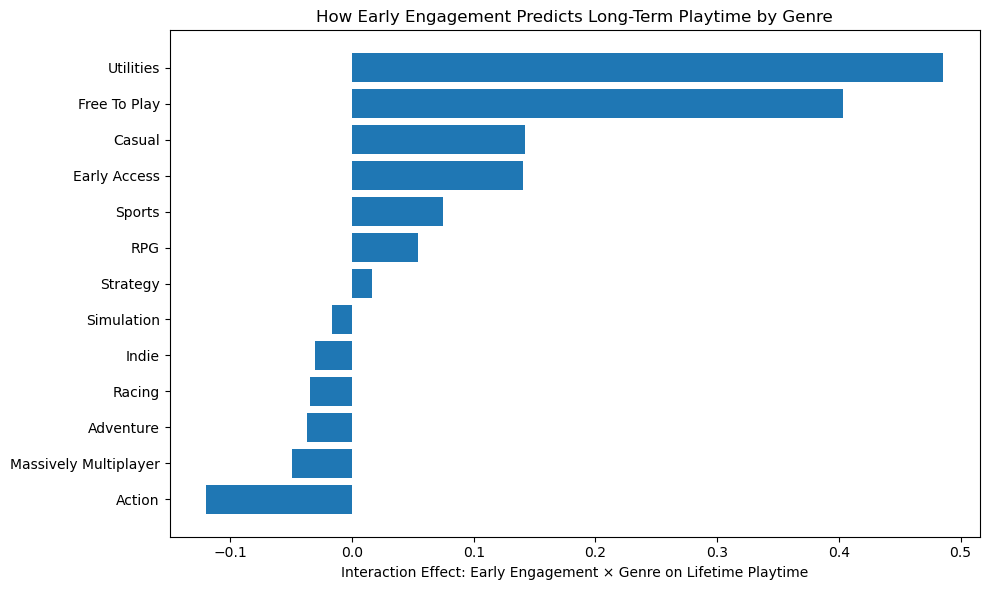

In [68]:
# Visualize genre interaction effects
genre_effects["genre"] = genre_effects["Feature"].str.replace("log_early_x_", "")

plt.figure(figsize=(10, 6))
plt.barh(genre_effects["genre"], genre_effects["Coefficient"])
plt.xlabel("Interaction Effect: Early Engagement × Genre on Lifetime Playtime")
plt.title("How Early Engagement Predicts Long-Term Playtime by Genre")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../Graphs/genre_early_engagement_effects.png", dpi=300)
plt.show()

**Figure 14 – Genre Differences in the Impact of Early Engagement**

The interaction coefficients reveal that the predictive value of early engagement varies considerably across genres. The two strongest positive interactions are:

- **Utilities** (+0.486): The largest interaction effect by a substantial margin. For Utilities-tagged games, early engagement is a particularly strong signal of long-term retention.
- **Free To Play** (+0.404): Early engagement is especially predictive of lifetime playtime for free-to-play titles, consistent with these games' dependence on sustained player activity for monetization.

Moderate positive interactions occur for Casual (+0.142), Early Access (+0.141), and Sports (+0.075). RPG (+0.054) and Strategy (+0.016) show small positive interactions near zero.

Negative interactions are small: Simulation (−0.017), Indie (−0.031), Adventure (−0.067), Racing (−0.105), Action (−0.127), and Massively Multiplayer (−0.148). For these genres, early engagement is a weaker — or even slightly counterproductive — predictor of long-term outcomes, possibly because they rely more on factors such as content updates, community events, or word-of-mouth growth that unfold independently of the launch window.

### Why Early Engagement Matters More for Free-to-Play Games

The strong interaction effect for Free-to-Play games (coef = +0.404) is consistent with the structural design of these titles. Free-to-play games monetize primarily through in-game purchases rather than upfront pricing, making sustained player activity central to their commercial model. Strong early engagement signals community formation, platform visibility through review accumulation, and the self-reinforcing social dynamics that tend to sustain long-term participation.

A related pattern appears for Utilities (+0.486) and Early Access (+0.141), categories where early adopters play a disproportionate role in shaping long-term outcomes through feedback, community development, and word-of-mouth.

For genres such as Massively Multiplayer (−0.148) and Action (−0.127), the negative interaction may reflect that long-term engagement in these categories is more dependent on post-launch content, competitive infrastructure, or social network effects that are not captured in the early two-week window.

## Week 6 – Model Robustness and Interpretation Depth

### Tuned Ridge and Lasso Regression (Time-Based Split)

In [69]:
# Ridge with cross-validated hyperparameter tuning
ridge = Ridge()
ridge_params = {"alpha": [0.01, 0.1, 1, 10, 100]}

ridge_cv = GridSearchCV(ridge, ridge_params, cv=5)
ridge_cv.fit(X_train_time, y_train_time)

ridge_pred = ridge_cv.predict(X_test_time)

# Lasso with cross-validated hyperparameter tuning
lasso = Lasso(max_iter=10000)
lasso_params = {"alpha": [0.001, 0.01, 0.1, 1, 10]}

lasso_cv = GridSearchCV(lasso, lasso_params, cv=5)
lasso_cv.fit(X_train_time, y_train_time)

lasso_pred = lasso_cv.predict(X_test_time)

### Evaluate Models

In [70]:
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} R\u00b2: {r2:.4f}")
    print(f"{name} RMSE: {rmse:.4f}\n")

evaluate_model("Linear", y_test_time, time_pred)
evaluate_model("Ridge", y_test_time, ridge_pred)
evaluate_model("Lasso", y_test_time, lasso_pred)

Linear R²: 0.5211
Linear RMSE: 1.9288

Ridge R²: 0.5210
Ridge RMSE: 1.9290

Lasso R²: 0.5203
Lasso RMSE: 1.9303



**Model Robustness: Ridge and Lasso on the Time-Based Split**

| Model | R² | RMSE |
|---|---|---|
| Linear | 0.5211 | 1.9288 |
| Ridge | 0.5210 | 1.9290 |
| Lasso | 0.5203 | 1.9303 |

All three models perform within 0.1% of each other on both metrics, confirming that the model structure is robust and that overfitting is not a meaningful concern. Regularization shrinks certain genre coefficients but does not alter the dominant predictors (review signals and early playtime), supporting the use of the unpenalised linear model as the primary specification for interpretability.

The consistent R² of approximately 0.521 across all three time-validated models represents the core finding of the analysis: early engagement signals, player review volume, and genre characteristics together explain roughly half of the variance in long-term playtime for games released after the training window — a meaningful and stable predictive relationship with practical implications for game development and platform strategy.